# Data Science Job Salaries Data Handling & Analysis

**Dataset :** `ds_salaries.csv` (Data Science Job Salary dataset)  
**Objectifs :**
- Min-Max Normalization de la colonne `salary_in_usd`
- Réduction de dimension (PCA + t-SNE)
- Agrégation par `experience_level` (moyenne et médiane de salaire)


## 📦 Imports & chargement

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (11, 5)
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('datascience_salaries.csv')
print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
df.head()


Shape : (1171, 7)
Colonnes : ['Unnamed: 0', 'job_title', 'job_type', 'experience_level', 'location', 'salary_currency', 'salary']


,Unnamed: 0,job_title,job_type,experience_level,location,salary_currency,salary
0,0,Data scientist,Full Time,Senior,New York City,USD,149000
1,2,Data scientist,Full Time,Senior,Boston,USD,120000
2,3,Data scientist,Full Time,Senior,London,USD,68000
3,4,Data scientist,Full Time,Senior,Boston,USD,120000
4,5,Data scientist,Full Time,Senior,New York City,USD,149000


In [5]:
# Aperçu rapide
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isnull().sum())
print("\nStatistiques descriptives :")
df.describe()


Unnamed: 0          int64
job_title             str
job_type              str
experience_level      str
location              str
salary_currency       str
salary              int64
dtype: object

Valeurs manquantes :
Unnamed: 0          0
job_title           0
job_type            0
experience_level    0
location            0
salary_currency     0
salary              0
dtype: int64

Statistiques descriptives :


,Unnamed: 0,salary
count,1171.000000,1171.000000
mean,931.620837,64836.037575
std,647.445266,32551.767046
min,0.000000,30000.000000
25%,364.500000,45000.000000
50%,815.000000,63000.000000
75%,1504.500000,68000.000000
max,2259.000000,228000.000000


---
## Partie 1: Min-Max Normalization de `salary_in_usd`

In [10]:
# Colonne cible : salary_in_usd (montant standardisé en dollars)
salary_col = 'salary'
# print(df.columns.tolist())
print(f"Salaire min : ${df[salary_col].min():,}")
print(f"Salaire max : ${df[salary_col].max():,}")
print(f"Salaire moyen : ${df[salary_col].mean():,.0f}")

Salaire min : $30,000
Salaire max : $228,000
Salaire moyen : $64,836


In [11]:
# Application du MinMaxScaler
scaler = MinMaxScaler()
df['salary_normalized'] = scaler.fit_transform(df[[salary_col]])

print("Après normalisation Min-Max :")
print(df['salary_normalized'].describe().round(4))
print(f"\nMin normalisé : {df['salary_normalized'].min()}")
print(f"Max normalisé : {df['salary_normalized'].max()}")


Après normalisation Min-Max :
count    1171.0000
mean        0.1759
std         0.1644
min         0.0000
25%         0.0758
50%         0.1667
75%         0.1919
max         1.0000
Name: salary_normalized, dtype: float64

Min normalisé : 0.0
Max normalisé : 1.0


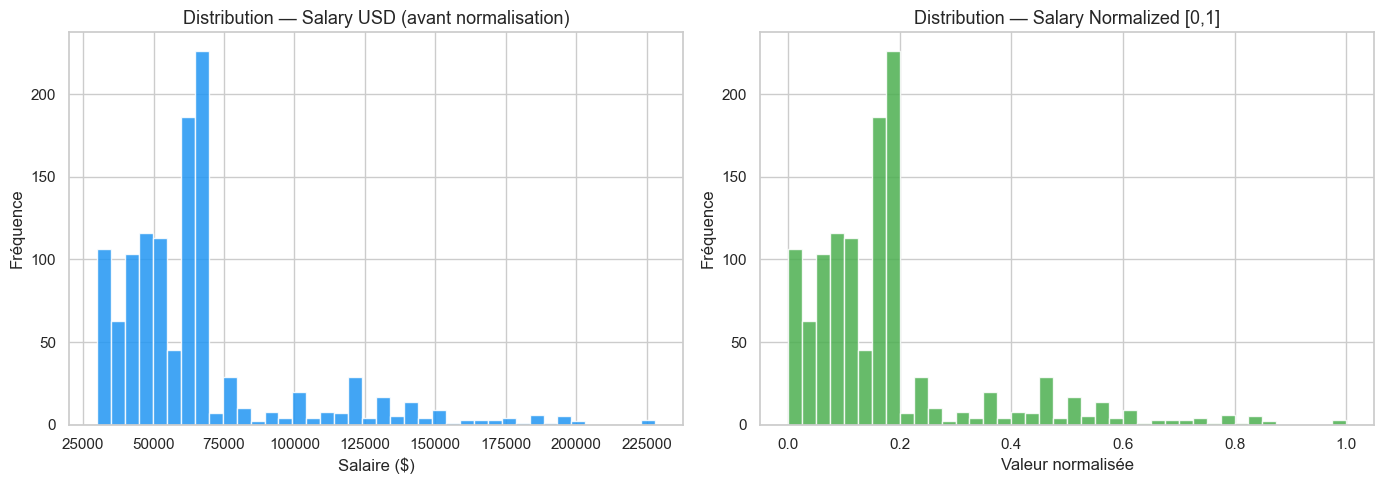

Figure sauvegardée : salary_normalization.png


In [12]:
# Visualisation avant / après normalisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[salary_col], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution — Salary USD (avant normalisation)', fontsize=13)
axes[0].set_xlabel('Salaire ($)')
axes[0].set_ylabel('Fréquence')

axes[1].hist(df['salary_normalized'], bins=40, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution — Salary Normalized [0,1]', fontsize=13)
axes[1].set_xlabel('Valeur normalisée')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig('salary_normalization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : salary_normalization.png")



## Partie 2: Réduction de dimension (PCA + t-SNE)


In [16]:
# Sélection des colonnes numériques + encodage des catégorielles utiles
# Colonnes catégorielles à encoder
cat_cols = ['experience_level', 'job_type', 'job_title', 'location']

# Colonnes numériques déjà disponibles
num_cols = ['salary']

# Encodage Label Encoding pour réduire la dimensionalité des catégorielles
df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col].astype(str))

# Dataset pour PCA/t-SNE
feature_cols = num_cols + [c + '_enc' for c in cat_cols]
X = df_encoded[feature_cols].copy()

# Standardisation préalable (recommandée avant PCA)
scaler_std = StandardScaler()
X_scaled = scaler_std.fit_transform(X)

print(f"Dimensions du dataset avant réduction : {X_scaled.shape}")
print(f"Features utilisées : {feature_cols}")


Dimensions du dataset avant réduction : (1171, 5)
Features utilisées : ['salary', 'experience_level_enc', 'job_type_enc', 'job_title_enc', 'location_enc']


In [ ]:
# PCA
# On réduit à 2 composantes principales pour visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée par les 2 composantes PCA :")
print(f"  PC1 : {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2 : {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total : {pca.explained_variance_ratio_.sum()*100:.1f}%")

df_encoded['PCA_1'] = X_pca[:, 0]
df_encoded['PCA_2'] = X_pca[:, 1]


Variance expliquée par les 2 composantes PCA :
  PC1 : 29.5%
  PC2 : 23.9%
  Total : 53.4%


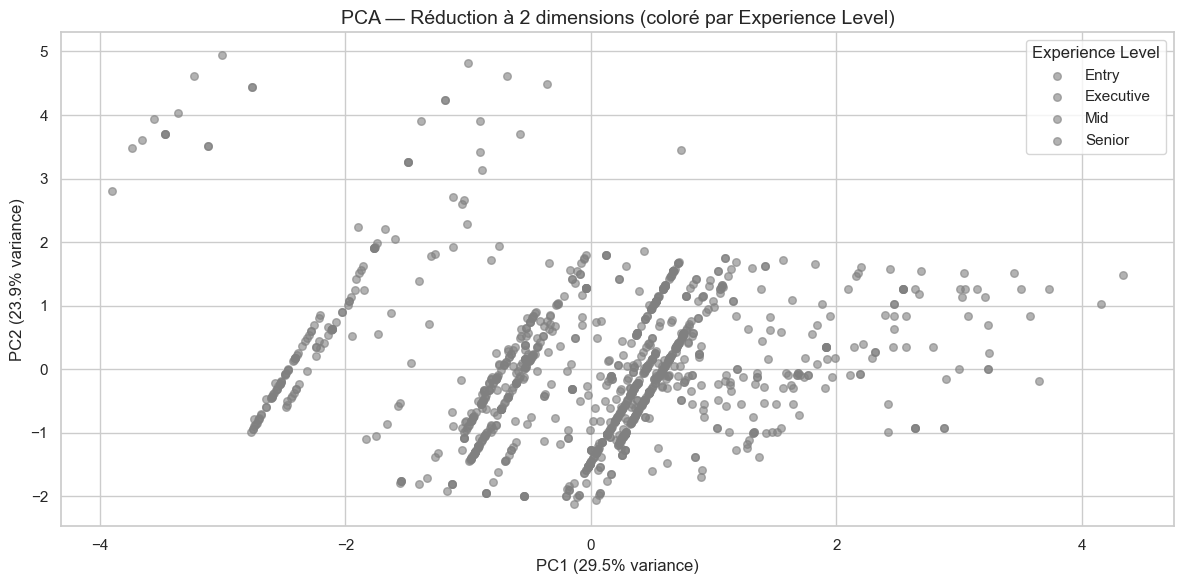

Figure sauvegardée : pca_visualization.png


In [18]:
# Visualisation PCA — coloré par experience_level
exp_palette = {'EN': '#FF6B6B', 'MI': '#4ECDC4', 'SE': '#45B7D1', 'EX': '#96CEB4'}

plt.figure(figsize=(12, 6))
for exp, grp in df_encoded.groupby('experience_level'):
    plt.scatter(grp['PCA_1'], grp['PCA_2'],
                label=exp, alpha=0.6, s=30,
                color=exp_palette.get(exp, 'gray'))

plt.title('PCA — Réduction à 2 dimensions (coloré par Experience Level)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Experience Level', loc='best')
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : pca_visualization.png")


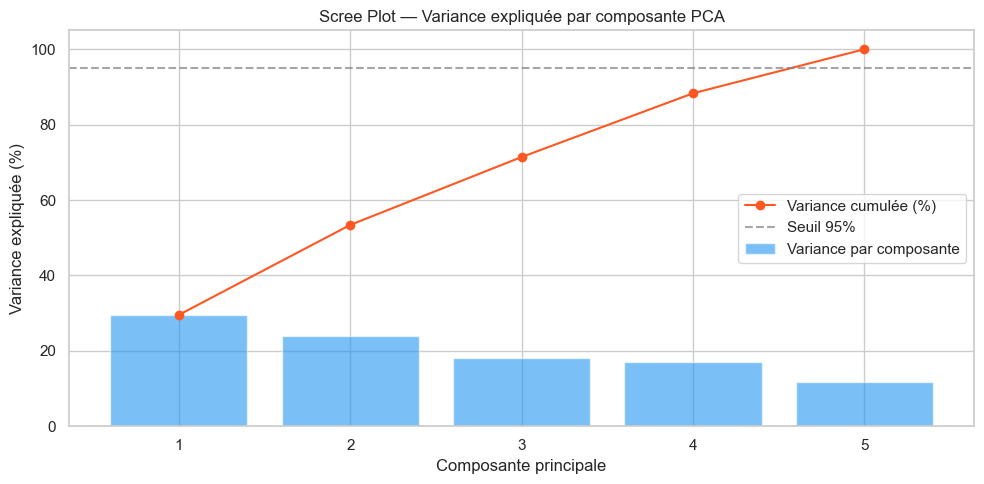

Composantes nécessaires pour 95% de variance : 5


In [19]:
# Scree Plot : combien de composantes retenir ?
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(cumvar)+1), pca_full.explained_variance_ratio_*100,
        alpha=0.6, color='#2196F3', label='Variance par composante')
plt.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#FF5722',
         label='Variance cumulée (%)')
plt.axhline(y=95, linestyle='--', color='gray', alpha=0.7, label='Seuil 95%')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée (%)')
plt.title('Scree Plot — Variance expliquée par composante PCA')
plt.legend()
plt.tight_layout()
plt.savefig('pca_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Nombre de composantes pour 95% de variance
n_95 = np.argmax(cumvar >= 95) + 1
print(f"Composantes nécessaires pour 95% de variance : {n_95}")


In [24]:
# t-SNE
# t-SNE est non-linéaire et excellent pour la visualisation 2D des clusters
# Note : plus lent que PCA, on utilise un subset si le dataset est grand

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


sample_size = min(1000, len(X_scaled))  # Limite à 1000 lignes pour la vitesse
idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_tsne_input = X_scaled[idx]
exp_tsne = df_encoded['experience_level'].iloc[idx].values
"""
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=300)
X_tsne = tsne.fit_transform(X_tsne_input)

print(f"t-SNE appliqué sur {sample_size} échantillons.")
"""
# Change n_iter=300 to max_iter=300
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=300)
X_tsne = tsne.fit_transform(X_tsne_input)

print(f"t-SNE appliqué sur {sample_size} échantillons.")

t-SNE appliqué sur 1000 échantillons.


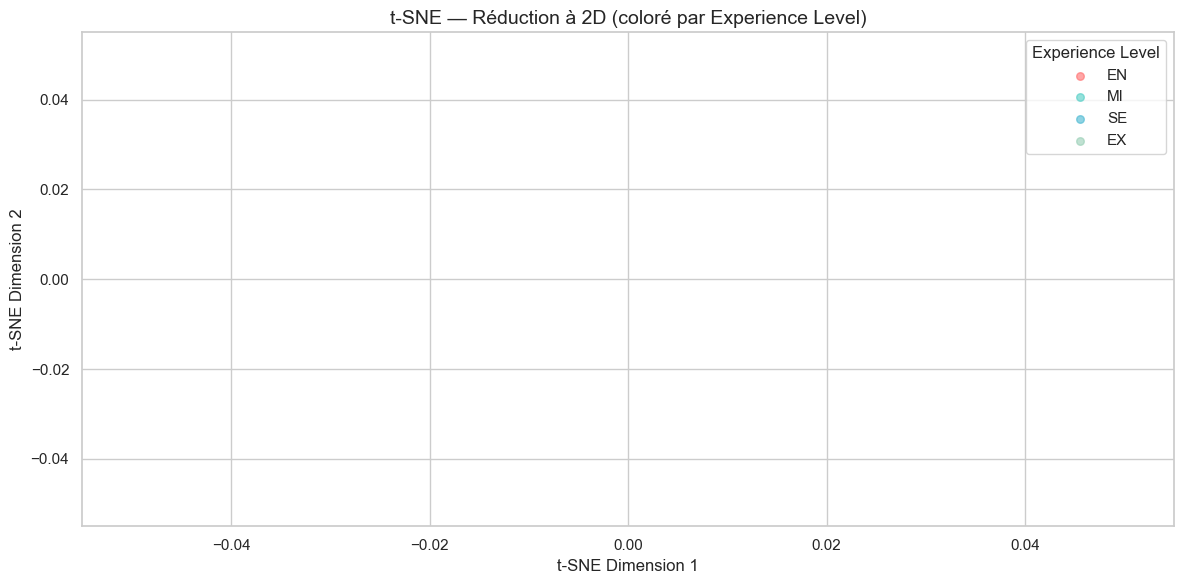

Figure sauvegardée : tsne_visualization.png


In [25]:
# Visualisation t-SNE
plt.figure(figsize=(12, 6))
for exp in ['EN', 'MI', 'SE', 'EX']:
    mask = exp_tsne == exp
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=exp, alpha=0.6, s=30,
                color=exp_palette.get(exp, 'gray'))

plt.title('t-SNE — Réduction à 2D (coloré par Experience Level)', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Experience Level')
plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : tsne_visualization.png")


---
## Partie 3: Agrégation par `experience_level`


In [27]:
# Agrégation : moyenne et médiane du salaire par experience_level
agg = df.groupby('experience_level')['salary'].agg(
    Count='count',
    Mean_Salary='mean',
    Median_Salary='median',
    Std_Salary='std',
    Min_Salary='min',
    Max_Salary='max'
).round(0)

# Trier par médiane croissante
agg = agg.sort_values('Median_Salary')

print("Statistiques salariales par niveau d'expérience :")
print(agg.to_string())


Statistiques salariales par niveau d'expérience :
                  Count  Mean_Salary  Median_Salary  Std_Salary  Min_Salary  Max_Salary
experience_level                                                                       
Entry               126      36111.0        30000.0     16151.0       30000      140000
Executive            13      76077.0        46000.0     46861.0       41000      175000
Mid                 305      51787.0        51000.0     20610.0       30000      160000
Senior              727      75088.0        68000.0     33561.0       30000      228000


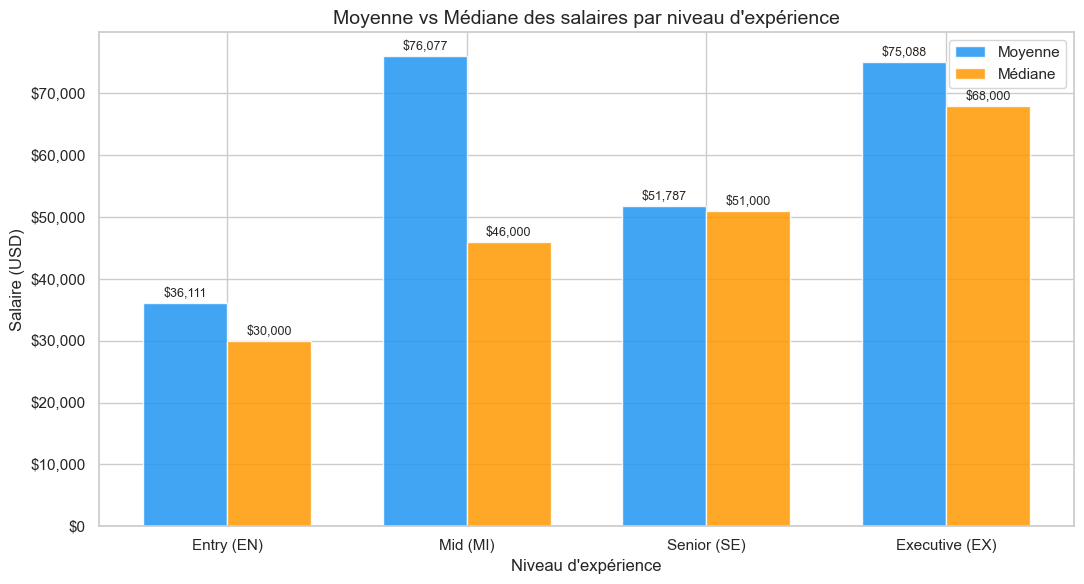

Figure sauvegardée : salary_by_experience.png


In [30]:
# Visualisation : Moyenne vs Médiane par niveau d'expérience
exp_order = agg.index.tolist()
x = np.arange(len(exp_order))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, agg['Mean_Salary'], width, label='Moyenne', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, agg['Median_Salary'], width, label='Médiane', color='#FF9800', alpha=0.85)

ax.set_xlabel("Niveau d'expérience", fontsize=12)
ax.set_ylabel('Salaire (USD)', fontsize=12)
ax.set_title("Moyenne vs Médiane des salaires par niveau d'expérience", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Entry (EN)', 'Mid (MI)', 'Senior (SE)', 'Executive (EX)'])
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

# Annotations
for bar in bars1:
    ax.annotate(f'${bar.get_height():,.0f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'${bar.get_height():,.0f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('salary_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : salary_by_experience.png")


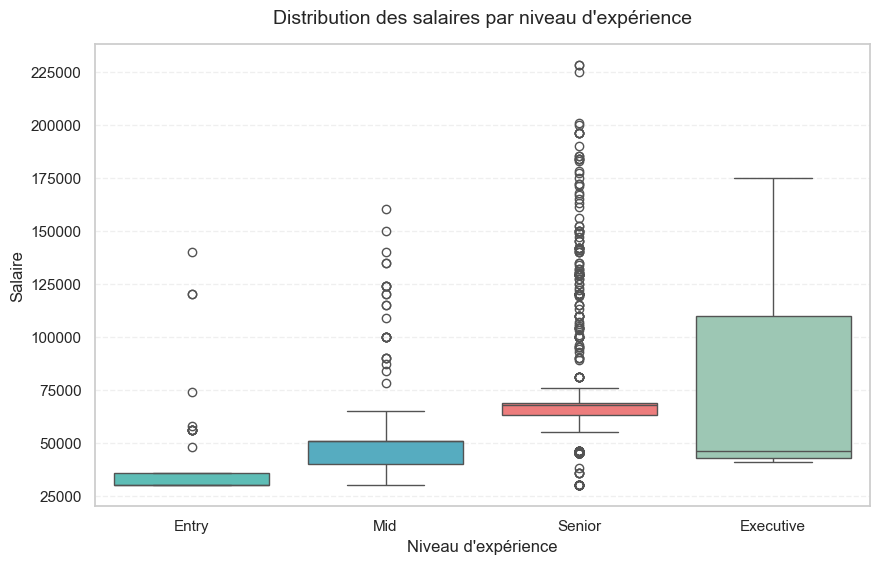

'\nplt.figure(figsize=(11, 6))\norder = [\'EN\', \'MI\', \'SE\', \'EX\']\nlabels_map = {\'EN\': \'Entry-level\', \'MI\': \'Mid-level\', \'SE\': \'Senior\', \'EX\': \'Executive\'}\n\ndf[\'exp_label\'] = df[\'experience_level\'].map(labels_map)\norder_labels = [labels_map[o] for o in order]\n\nsns.boxplot(data=df, x=\'exp_label\', y=\'salary\',\n            order=order_labels,\n            palette=[\'#FF6B6B\', \'#4ECDC4\', \'#45B7D1\', \'#96CEB4\'])\n\nplt.title("Distribution des salaires par niveau d\'expérience", fontsize=14)\nplt.xlabel("Niveau d\'expérience", fontsize=12)\nplt.ylabel(\'Salaire (USD)\', fontsize=12)\nplt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f\'${v:,.0f}\'))\nplt.tight_layout()\nplt.savefig(\'salary_boxplot_experience.png\', dpi=150, bbox_inches=\'tight\')\nplt.show()\nprint("Figure sauvegardée : salary_boxplot_experience.png")\n'

In [37]:
# Boxplot : distribution complète des salaires par niveau

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map the experience levels to your ordered labels
labels_map = {'Entry': 'Entry', 'Mid': 'Mid', 'Senior': 'Senior', 'Executive': 'Executive'}
order_labels = ['Entry', 'Mid', 'Senior', 'Executive']

df['exp_label'] = df['experience_level'].map(labels_map)

# 2. Setup the plot figure
plt.figure(figsize=(10, 6))

# 3. Create the boxplot with explicit hue mapping to prevent the local variable crash
sns.boxplot(
    data=df, 
    x='exp_label', 
    y='salary',     
    hue='exp_label',  # Explicitly defined to fix the Seaborn/Python 3.14 bug
    order=order_labels,     
    palette=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'],
    legend=False      # Suppresses duplicate legends
)

# 4. Add titles and layout styling
plt.title("Distribution des salaires par niveau d'expérience", fontsize=14, pad=15)
plt.xlabel("Niveau d'expérience", fontsize=12)
plt.ylabel("Salaire", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# 5. Save and display
plt.savefig('salary_by_experience.png', bbox_inches='tight')
plt.show()

"""
plt.figure(figsize=(11, 6))
order = ['EN', 'MI', 'SE', 'EX']
labels_map = {'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}

df['exp_label'] = df['experience_level'].map(labels_map)
order_labels = [labels_map[o] for o in order]

sns.boxplot(data=df, x='exp_label', y='salary',
            order=order_labels,
            palette=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])

plt.title("Distribution des salaires par niveau d'expérience", fontsize=14)
plt.xlabel("Niveau d'expérience", fontsize=12)
plt.ylabel('Salaire (USD)', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.savefig('salary_boxplot_experience.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : salary_boxplot_experience.png")
"""
